# V2 — Environment Testing — 1H Data

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = (Path.cwd() / "../.." ).resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from stable_baselines3.common.env_checker import check_env
from src.environment.trading_env import TradingEnv

plt.style.use("seaborn-v0_8-darkgrid")
print(f"Project root: {PROJECT_ROOT}")

cfg = yaml.safe_load(open(PROJECT_ROOT / "configs/dqn_config.yaml"))
ENV_CFG = cfg["environment"]
print(f"initial_balance : {ENV_CFG['initial_balance']}")
print(f"transaction_cost: {ENV_CFG['transaction_cost']}")


Project root: /Users/nuwan/Work/UoM/MDSAI_2025/semester3/capstone-project/project/reinforcement-based-cryptocurrency-trading-strategy
initial_balance : 10000.0
transaction_cost: 0.001


## 1. Load Normalised Data

In [2]:
df_train = pd.read_csv(PROJECT_ROOT / "data/normalized/train.csv", index_col=0, parse_dates=True)
df_val   = pd.read_csv(PROJECT_ROOT / "data/normalized/val.csv",   index_col=0, parse_dates=True)
df_test  = pd.read_csv(PROJECT_ROOT / "data/normalized/test.csv",  index_col=0, parse_dates=True)
print(f"Train : {len(df_train):,} rows")
print(f"Val   : {len(df_val):,} rows")
print(f"Test  : {len(df_test):,} rows")


Train : 23,326 rows
Val   : 720 rows
Test  : 2,208 rows


## 2. SB3 Environment Check

In [3]:
print("Loading training data...")
print(f"  Rows     : {len(df_train):,}")
print(f"  Columns  : {list(df_train.columns)}")
print(f"  Obs range: [{df_train.values.min():.4f}, {df_train.values.max():.4f}]")
print()

print("Building TradingEnv...")
env = TradingEnv(df_train, ENV_CFG)
print(f"  Action space     : {env.action_space}")
print(f"  Observation space: {env.observation_space}")
print(f"  Episode steps    : {env.n_steps:,}")
print()

print("Running SB3 check_env...")
check_env(env)
print("check_env PASSED")


Loading training data...
  Rows     : 23,326
  Columns  : ['open', 'high', 'low', 'close', 'volume', 'sma_10', 'sma_50', 'rsi', 'momentum_5']
  Obs range: [-10.6235, 91.8422]

Building TradingEnv...
  Action space     : Discrete(3)
  Observation space: Box(0.0, 1.0, (11,), float32)
  Episode steps    : 23,326

Running SB3 check_env...
check_env PASSED


## 3. Episode Smoke Test (Train)

In [4]:
env = TradingEnv(df_train, cfg["environment"])
obs, _ = env.reset()
print(f"Obs shape : {obs.shape}")
print(f"Obs range : [{obs.min():.4f}, {obs.max():.4f}]")
print(f"Episode steps (train): {env.n_steps:,}")

total_reward = 0
for _ in range(env.n_steps):
    action = env.action_space.sample()
    obs, reward, done, _, info = env.step(action)
    total_reward += reward
    if done:
        break

print(f"Random-policy total reward: {total_reward:.4f}")
print(f"Random-policy total return: {env.total_return:.2f}%")


Obs shape : (11,)
Obs range : [0.0000, 0.5451]
Episode steps (train): 23,326
Random-policy total reward: -0.6309
Random-policy total return: -100.00%


## 4. Baseline — Random Policy Distribution (Val)

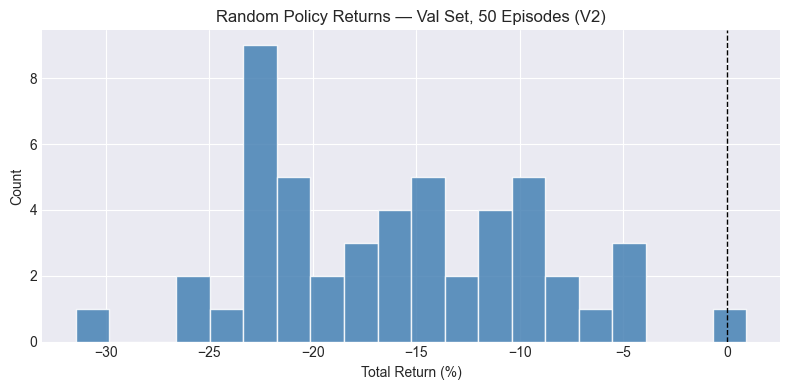

Mean: -15.97%  Min: -31.46%  Max: 0.94%


In [5]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-darkgrid")

returns = []
for _ in range(50):
    env_v = TradingEnv(df_val, cfg["environment"])
    obs, _ = env_v.reset()
    done = False
    while not done:
        obs, _, done, _, _ = env_v.step(env_v.action_space.sample())
    returns.append(env_v.total_return)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(returns, bins=20, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Total Return (%)")
ax.set_ylabel("Count")
ax.set_title("Random Policy Returns — Val Set, 50 Episodes (V2)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v2_03_random_policy_returns.png", dpi=150)
plt.show()
print(f"Mean: {sum(returns)/len(returns):.2f}%  Min: {min(returns):.2f}%  Max: {max(returns):.2f}%")


## 5. Baseline Strategies (Val)

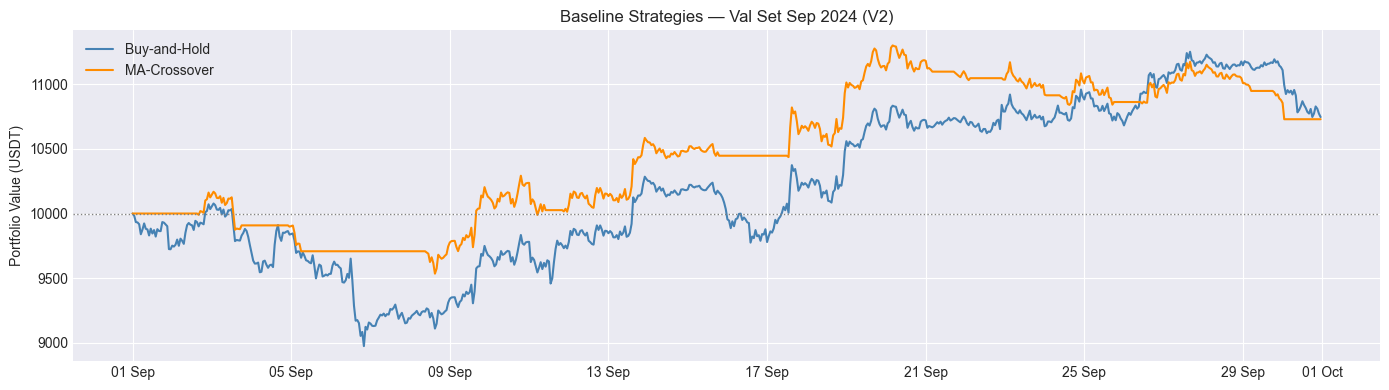

Buy-and-Hold return (Sep 2024): +7.35%
MA-Crossover return (Sep 2024): +7.29%


In [6]:
from src.agents import buy_and_hold, ma_crossover

df_val_feat = pd.read_csv(PROJECT_ROOT / "data/features/val.csv", index_col=0, parse_dates=True)

ib = ENV_CFG["initial_balance"]
tc = ENV_CFG["transaction_cost"]

bh_trace = buy_and_hold.run(df_val_feat, initial_balance=ib, transaction_cost=tc)
ma_trace = ma_crossover.run(df_val_feat, initial_balance=ib, transaction_cost=tc)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_val_feat.index, bh_trace["portfolio_value"] / bh_trace["portfolio_value"].iloc[0] * ib, label="Buy-and-Hold", color="steelblue")
ax.plot(df_val_feat.index, ma_trace["portfolio_value"] / ma_trace["portfolio_value"].iloc[0] * ib, label="MA-Crossover",  color="darkorange")
ax.axhline(ib, color="grey", linestyle=":", linewidth=1)
ax.set_title("Baseline Strategies — Val Set Sep 2024 (V2)")
ax.set_ylabel("Portfolio Value (USDT)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results/figures/v2_03_baseline_comparison_val.png", dpi=150)
plt.show()

bh_ret = (bh_trace["portfolio_value"].iloc[-1] / ib - 1) * 100
ma_ret = (ma_trace["portfolio_value"].iloc[-1] / ib - 1) * 100
print(f"Buy-and-Hold return (Sep 2024): {bh_ret:+.2f}%")
print(f"MA-Crossover return (Sep 2024): {ma_ret:+.2f}%")
